In [1]:
import scanpy as sc
import anndata as ad
from scipy import stats
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import matplotlib as mpl
from scipy.stats import entropy
from mygene import MyGeneInfo
from collections import defaultdict

import sys
sys.path.append("/mnt/research/FishEvoDevoGeno/Hao/icepop/icepop")
from metacell import metacell
from convert_score_across_species import CrossSpeciesScoreConverter

pd.set_option('display.max_rows', None)

# load data

In [2]:
adata = sc.read('../data/sc_data/TM_FACS_MetaQ.h5ad')

In [3]:
def entrez_to_symbol(entrez_ids, species='human'):
    mg = MyGeneInfo()
    res = mg.querymany(
        entrez_ids,
        scopes='entrezgene',
        fields='symbol',
        species=species,
        as_dataframe=False
    )

    return {
        str(r['query']): r.get('symbol', None)
        for r in res
        if not r.get('notfound', False)
    }

In [4]:
trait_df = pd.read_csv('../data/trait_name_map.tsv', header=0, index_col=0, sep='\t')
trait_df = trait_df[trait_df['include'] == 'Yes']
traits = trait_df.index.values
short_names = trait_df['trait_short_name'].values

In [5]:
indir = '../results/2026-01-11__gls'

# load metacell betas
files = Path(indir).glob('metacell__trait*.csv')
files = [str(i) for i in files]

icepop_df = []
for file in files:
    trait = Path(file).stem.split('__trait-')[1]
    df = pd.read_csv(file, header=0, index_col=None)
    df = df.loc[:, ['metacell', 'z']].set_index('metacell')
    df = df.rename(columns={'z': trait})
    icepop_df.append(df)
icepop_df = pd.concat(icepop_df, axis=1)
icepop_df = icepop_df.T

In [6]:
metacells = np.asarray(icepop_df.columns)
icepop_df = icepop_df.loc[traits, :].copy()

# clustering on mahalanobis distance

In [7]:
def clustering_mahalanobis(
    betas, Sigma_inv,
    k=5, resolution=1,
    random_state=1,
    distance='mahalanobis'
):
    """
    Spectral clustering using Mahalanobis-based similarity
    """
    n_diseases = betas.shape[0]
    
    # ------------------------------------------------------------
    # 1. Compute Mahalanobis squared distances
    # ------------------------------------------------------------
    D2 = np.zeros((n_diseases, n_diseases))
    
    for i in range(n_diseases):
        for j in range(i+1, n_diseases):
            
            if distance=='mahalanobis':
                diff = betas[i] - betas[j]
                d2 = diff @ Sigma_inv @ diff
            elif distance=='mahalanobis_cos':
                d2 = mahalanobis_cos(betas[i], betas[j], Sigma_inv)
                d2 = 1 - d2
            elif distance=='euclidean':
                diff = betas[i] - betas[j]
                d2 = np.sum(diff ** 2)
            D2[i, j] = d2
            D2[j, i] = d2
    np.fill_diagonal(D2, 0.0)

    # ------------------------------------------------------------
    # 2. Build k-NN graph (based on distances)
    # ------------------------------------------------------------
    idx = np.argsort(D2, axis=1)[:, 1:k+1]   # skip itself

    # weighted adjacency matrix
    W = np.zeros_like(D2)

    # ------------------------------------------------------------
    # 3. Smooth neighbors by Gaussian kernel
    # ------------------------------------------------------------

    # use median heuristic for sigma^2
    sigma2 = np.median(D2[D2 > 0])

    for i in range(n_diseases):
        for j in idx[i]:
            w = np.exp(-D2[i, j] / (2 * sigma2))
            W[i, j] = w
            W[j, i] = w  # symmetrize

    # ------------------------------------------------------------
    # 4. Build weighted graph + run Louvain
    # ------------------------------------------------------------
    # create graph from weighted adjacency matrix
    G = nx.from_numpy_array(W)

    # remove self-loops and zero-weight edges
    G.remove_edges_from([
        (u, v) for u, v, w in G.edges(data="weight") if w == 0
    ])

    # run Louvain
    partition = nx.community.louvain_communities(
        G, weight='weight',
        resolution=resolution, seed=random_state
    )
    # initialize labels with -1
    labels = np.full(G.number_of_nodes(), -1, dtype=int)
    # assign community id
    for cid, community in enumerate(partition):
        for node in community:
            labels[node] = cid
    return labels, W, D2


def plot_knn_graph(
    W, names,
    labels=None, node_size=400,
    figsize=(8, 9), random_state=42
):
    """
    Plot weighted kNN graph W with node labels from names list,
    and add legends for edge and node colors.
    """

    # build graph
    G = nx.from_numpy_array(W)

    # remove zero-weight edges
    G.remove_edges_from([(u,v) for u,v,w in G.edges(data='weight') if w == 0])

    plt.figure(figsize=figsize)
    
    # layout (weighted spring)
    pos = nx.spring_layout(G, weight='weight', seed=random_state)

    # ===========================
    # NODE COLORS
    # ===========================
    if labels is not None:
        node_color = labels
        node_cmap = plt.cm.tab10
        unique_labels = sorted(set(labels))
    else:
        node_color = 'skyblue'
        node_cmap = None

    # draw nodes
    nodes = nx.draw_networkx_nodes(
        G, pos,
        node_size=node_size,
        node_color=node_color,
        cmap=node_cmap,
        edgecolors='black'
    )

    # ===========================
    # EDGE COLORS
    # ===========================
    weights = nx.get_edge_attributes(G, 'weight')
    edges, w = zip(*weights.items())

    edge_plot = nx.draw_networkx_edges(
        G, pos,
        edgelist=edges,
        width=[4*x for x in w],
        edge_color=w,
        edge_cmap=plt.cm.Blues,
        alpha=0.8,
    )

    # ===========================
    # NODE LABELS
    # ===========================
    for i, (x, y) in pos.items():
        plt.text(
            x + 0.01, y + 0.01, 
            names[i], fontsize=7
        )

    # ===========================
    # LEGEND: EDGE COLORBAR
    # ===========================
    sm = mpl.cm.ScalarMappable(
        cmap=plt.cm.Blues,
        norm=plt.Normalize(vmin=min(w), vmax=max(w))
    )
    sm._A = []  # necessary trick for old mpl versions

    ax = plt.gca()
    cbar = plt.colorbar(
        sm, 
        ax=ax,              # <-- important fix
        fraction=0.03, 
        pad=0.02
    )
    cbar.set_label("Edge Weight (Similarity)")

    # ===========================
    # CLEANUP AND SHOW
    # ===========================
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def quantile_normalize(X):
    """
    Quantile-normalize rows of a matrix (traits × genes).

    Parameters
    ----------
    X : np.ndarray, shape (n_traits, n_genes)
        Input matrix (e.g. MAGMA Z-scores).

    Returns
    -------
    X_qn : np.ndarray, same shape as X
        Quantile-normalized matrix.
    """

    X = np.asarray(X, dtype=float)

    # 1. sort each row
    X_sorted = np.sort(X, axis=1)

    # 2. compute mean quantile across cols
    mean_quantiles = X_sorted.mean(axis=0)

    # 3. get ranks within each row
    ranks = np.argsort(np.argsort(X, axis=1), axis=1)

    # 4. map ranks to mean quantiles
    X_qn = mean_quantiles[ranks]

    return X_qn

## Disease zscore based distance

In [8]:
# get zscore
files = Path('../data/gwas/zstat').glob('*.csv')
z_dfs = []
for file in files:
    name = Path(file).stem
    df = pd.read_csv(file, header=0, index_col=None)
    df['GENE'] = df['GENE'].astype(str)
    df['trait'] = name
    z_dfs.append(df)
z_df = pd.concat(z_dfs)

# get shared genes across all triats
cnt = z_df['GENE'].value_counts()
z_shared_genes = cnt[cnt == 84].index.values

# get zscore mat
z_mat = {}
for df in z_dfs:
    df_indexed = df.set_index('GENE')
    z_mat[df_indexed['trait'].iloc[0]] = df_indexed.loc[z_shared_genes, 'ZSTAT']
z_mat = pd.DataFrame(z_mat)
z_mat = z_mat.loc[:, traits].copy()
z_mat = z_mat.T

# quantile normalize zscore
z_mat_norm = quantile_normalize(z_mat.to_numpy())

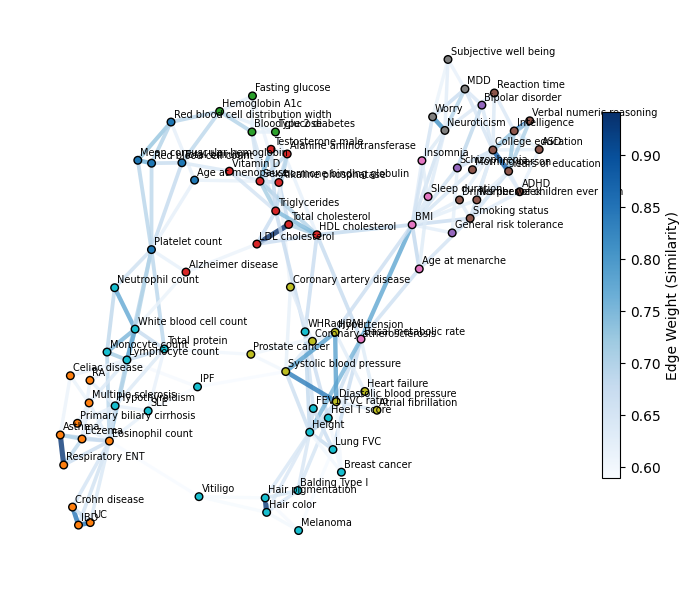

In [9]:
# clustering on euclidean distance without considering covar
labels, W, D2 = clustering_mahalanobis(
    z_mat_norm, None, distance='euclidean',
    k=3, resolution=2.5, random_state=42
)

gwasz_W_df = pd.DataFrame(W, index=short_names, columns=short_names)
gwasz_clus_df = (
    gwasz_W_df
    .where(np.triu(np.ones(gwasz_W_df.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={
        'level_0': 'trait1',
        'level_1': 'trait2',
        0: 'simi'
    })
)

plot_knn_graph(W, short_names, labels=labels, node_size=30, figsize=(7, 6), random_state=1)

In [10]:
cluster_df = pd.DataFrame(zip(traits, short_names, labels), columns=['trait', 'short_name', 'cluster'])
cluster_df.to_csv('../paper/supp/gwas_clus.csv', header=True, index=False)
cluster_df.sort_values(by='cluster')

,trait,short_name,cluster
80,UKB_460K.repro_MENOPAUSE_AGE,Age at menopause,0
31,UKB_460K.biochemistry_TotalBilirubin,Total bilirubin,0
5,UKB_460K.blood_PLATELET_COUNT,Platelet count,0
3,UKB_460K.blood_MEAN_CORPUSCULAR_HEMOGLOBIN,Mean corpuscular hemoglobin,0
7,UKB_460K.blood_RED_COUNT,Red blood cell count,0
6,UKB_460K.blood_RBC_DISTRIB_WIDTH,Red blood cell distribution width,0
9,PASS_CD_deLange2017,Crohn disease,1
10,PASS_Celiac,Celiac disease,1
68,UKB_460K.disease_RESPIRATORY_ENT,Respiratory ENT,1
67,UKB_460K.disease_ASTHMA_DIAGNOSED,Asthma,1


In [11]:
# remove self-loops (optional)
adj = pd.DataFrame(W, index=short_names, columns=short_names)

# remove self-loops (optional)
np.fill_diagonal(adj.values, 0)

# convert to edge list
edges = (
    adj
    .stack()
    .reset_index()
)

edges.columns = ["source", "target", "weight"]

# remove zero / NA edges
edges = edges.query("weight != 0")

# OPTIONAL: keep only upper triangle (undirected graph)
edges = edges[edges["source"] < edges["target"]]

# export
edges.to_csv("../paper/supp/cytoscape_edges_magma_W.tsv", sep="\t", index=False)



node_table = cluster_df.loc[:, ['short_name', 'cluster']].copy()
node_table.columns = ['node', 'cluster']
node_table.to_csv(
    "../paper/supp/cytoscape_magma_nodes.tsv",
    sep="\t",
    index=False
)

In [12]:
clus2name = defaultdict(list)
for name, clus in zip(cluster_df['short_name'], cluster_df['cluster']):
    clus2name[clus].append(name)
for clus, names in clus2name.items():
    print(','.join(names))

Neutrophil count,Lymphocyte count,Monocyte count,White blood cell count,SLE,Hypothyroidism,Total protein,IPF
Eosinophil count,Crohn disease,Celiac disease,IBD,Multiple sclerosis,Primary biliary cirrhosis,RA,UC,Eczema,Asthma,Respiratory ENT
Mean corpuscular hemoglobin,Platelet count,Red blood cell distribution width,Red blood cell count,Total bilirubin,Age at menopause
Vitiligo,WHRadjBMI,FEV1 FVC ratio,Lung FVC,Hair color,Melanoma,Heel T score,Balding Type I,Height,Breast cancer,Hair pigmentation
Fasting glucose,Type 2 diabetes,Blood glucose,Hemoglobin A1c
Alanine aminotransferase,Alkaline phosphatase,Total cholesterol,HDL cholesterol,LDL cholesterol,Sex hormone binding globulin,Testosterone male,Triglycerides,Vitamin D,Alzheimer disease
Basal metabolic rate,BMI,Insomnia,Sleep duration,Age at menarche
ASD,ADHD,Intelligence,Reaction time,Verbal numeric reasoning,Morning person,Drinks per week,College education,Years of education,Smoking status,Number of children ever born
Bipolar disorde

## metacell association based distance (euclidean)

In [13]:
from sklearn.decomposition import PCA
pca = PCA(n_components=50, svd_solver="full")  # choose pc number
X_pc = pca.fit_transform(icepop_df.values)            # shape (k, pc)
pc_df = pd.DataFrame(
    X_pc,
    index=icepop_df.index,
    columns=[f"PC{i+1}" for i in range(X_pc.shape[1])]
)

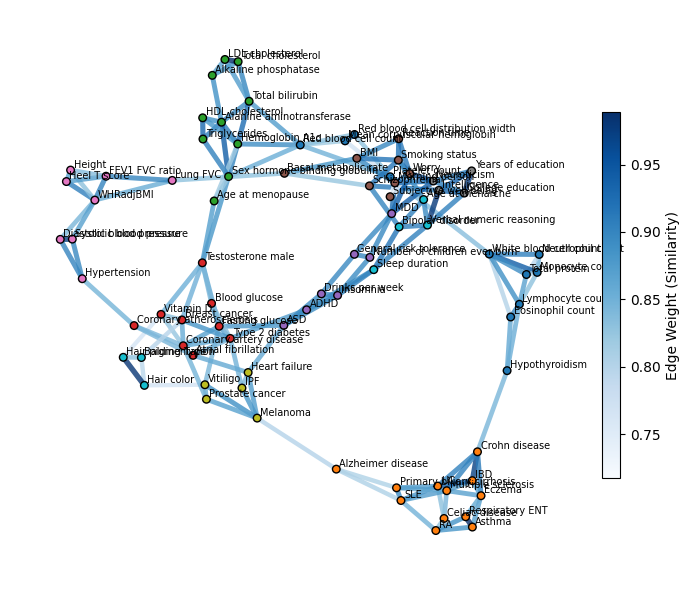

In [14]:
# clustering on euclidean distance without considering covar
labels, W, D2 = clustering_mahalanobis(
    pc_df.to_numpy(), None, distance='euclidean',
    k=3, resolution=2.5, random_state=42
)

mc_W_df = pd.DataFrame(W, index=short_names, columns=short_names)
mc_clus_df = (
    mc_W_df
    .where(np.triu(np.ones(mc_W_df.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={
        'level_0': 'trait1',
        'level_1': 'trait2',
        0: 'simi'
    })
)

plot_knn_graph(W, short_names, labels=labels, node_size=30, figsize=(7, 6), random_state=2)

In [15]:
cluster_df = pd.DataFrame(zip(traits, short_names, labels), columns=['trait', 'short_name', 'cluster'])
cluster_df.to_csv('../paper/supp/metacell_clus_euclidean.csv', header=True, index=False)
pd.DataFrame(W, index=short_names, columns=short_names).to_csv('../paper/supp/metacell_clus_euclidean_W.csv', header=True, index=True)
cluster_df.sort_values(by='cluster')

,trait,short_name,cluster
0,neutrophil_count,Neutrophil count,0
18,UKB_460K.disease_HYPOTHYROIDISM_SELF_REP,Hypothyroidism,0
4,UKB_460K.blood_MONOCYTE_COUNT,Monocyte count,0
8,UKB_460K.blood_WHITE_COUNT,White blood cell count,0
1,UKB_460K.blood_EOSINOPHIL_COUNT,Eosinophil count,0
2,UKB_460K.blood_LYMPHOCYTE_COUNT,Lymphocyte count,0
32,UKB_460K.biochemistry_TotalProtein,Total protein,0
6,UKB_460K.blood_RBC_DISTRIB_WIDTH,Red blood cell distribution width,1
3,UKB_460K.blood_MEAN_CORPUSCULAR_HEMOGLOBIN,Mean corpuscular hemoglobin,1
5,UKB_460K.blood_PLATELET_COUNT,Platelet count,1


In [16]:
# remove self-loops (optional)
adj = pd.DataFrame(W, index=short_names, columns=short_names)

# remove self-loops (optional)
np.fill_diagonal(adj.values, 0)

# convert to edge list
edges = (
    adj
    .stack()
    .reset_index()
)

edges.columns = ["source", "target", "weight"]

# remove zero / NA edges
edges = edges.query("weight != 0")

# OPTIONAL: keep only upper triangle (undirected graph)
edges = edges[edges["source"] < edges["target"]]

# export
edges.to_csv("../paper/supp/cytoscape_edges_euclidean_W.tsv", sep="\t", index=False)



node_table = cluster_df.loc[:, ['short_name', 'cluster']].copy()
node_table.columns = ['node', 'cluster']
node_table.to_csv(
    "../paper/supp/cytoscape_nodes.tsv",
    sep="\t",
    index=False
)

In [17]:
clus2name = defaultdict(list)
for name, clus in zip(cluster_df['short_name'], cluster_df['cluster']):
    clus2name[clus].append(name)
for clus, names in clus2name.items():
    print(','.join(names))

Neutrophil count,Eosinophil count,Lymphocyte count,Monocyte count,White blood cell count,Hypothyroidism,Total protein
Mean corpuscular hemoglobin,Platelet count,Red blood cell distribution width,Red blood cell count
Crohn disease,Celiac disease,IBD,SLE,Multiple sclerosis,Primary biliary cirrhosis,RA,UC,Eczema,Alzheimer disease,Asthma,Respiratory ENT
Vitiligo,Heart failure,IPF,Melanoma,Prostate cancer
Fasting glucose,Type 2 diabetes,Blood glucose,Testosterone male,Vitamin D,Coronary atherosclerosis,Atrial fibrillation,Coronary artery disease,Breast cancer
Alanine aminotransferase,Alkaline phosphatase,Total cholesterol,Hemoglobin A1c,HDL cholesterol,LDL cholesterol,Sex hormone binding globulin,Total bilirubin,Triglycerides,Age at menopause
WHRadjBMI,Diastolic blood pressure,Systolic blood pressure,Hypertension,FEV1 FVC ratio,Lung FVC,Heel T score,Height
Basal metabolic rate,BMI,Reaction time,Schizophrenia,Subjective well being,Worry,Morning person,Smoking status
ASD,ADHD,General risk tol

## separation of leukocyte count trait and autoimmune disease

In [18]:
leu_triats = cluster_df[cluster_df['cluster'] == 0]['trait'].values
auto_triats = cluster_df[cluster_df['cluster'] == 2]['trait'].values
foc_traits = np.concatenate([leu_triats, auto_triats])

indir = '../results/2026-01-11__gls'

icepop_ct_df = []
for trait in foc_traits:
    df = pd.read_csv(f'{indir}/celltype__trait-{trait}.csv', header=0, index_col=None)
    df['trait'] = trait
    icepop_ct_df.append(df)
icepop_ct_df = pd.concat(icepop_ct_df, axis=0, ignore_index=True)

# trait
trait_name_df = pd.read_csv('../data/trait_name_map.tsv', header=0, index_col=0, sep='\t')
# cell type
ct_name_df = pd.read_csv('../data/celltype_name_map.tsv', header=0, index_col=0, sep='\t')

In [19]:
cell_types_ordered = [

    # Blood progenitor
    "Hematopoietic stem cell",
    "Granulocyte monocyte progenitor cell",
    "Megakaryocyte-erythroid progenitor cell",
    "Granulocytopoietic cell",
    "Proerythroblast",
    "Late pro-B cell",
    "Precursor B cell",
    "Immature B cell",

    # Vascular
    "Endothelial cell",
    "Aortic endothelial cell",
    "Vein endothelial cell",
    "Capillary endothelial cells",
    "Endothelial cell of coronary artery",
    "Endothelial cell of hepatic sinusoid",
    "Fenestrated cell",
    "Smooth muscle cell of the pulmonary artery",
    "Valve cell",

    # Fibroblast
    "Kidney interstitial fibroblast",
    "Pulmonary interstitial fibroblast",
    "Fibrocyte",

    # Myeloid
    "Monocyte",
    "Classical monocyte",
    "Intermediate monocyte",
    "Non-classical monocyte",
    "Promonocyte",
    "Macrophage",
    "Lung macrophage",
    "Kupffer cell",
    "Microglial cell",
    "Dendritic cell",
    "Myeloid dendritic cell",
    "Plasmacytoid dendritic cell",
    "Neutrophil",
    "Granulocyte",
    "Basophil",
    "Myeloid cell",
    "Myeloid leukocyte",
    "Professional antigen presenting cell",
    "Leukocyte",

    # Lymphocytes
    "B cell",
    "Naive B cell",
    "Plasma cell",
    "CD4-positive, alpha-beta T cell",
    "CD8-positive, alpha-beta T cell",
    "Mature alpha-beta T cell",
    "Regulatory T cell",
    "T cell",
    "NK cell",
    "Mature NK T cell",
    "Lymphocyte",

    # Others
    "Epithelial cell",
    "Basal cell of epidermis",
    "Epithelial cell of proximal tubule",
    "Epithelial cell of thymus",
    "Atrial myocyte",
    "Thymocyte",
    "DN4 thymocyte",
]

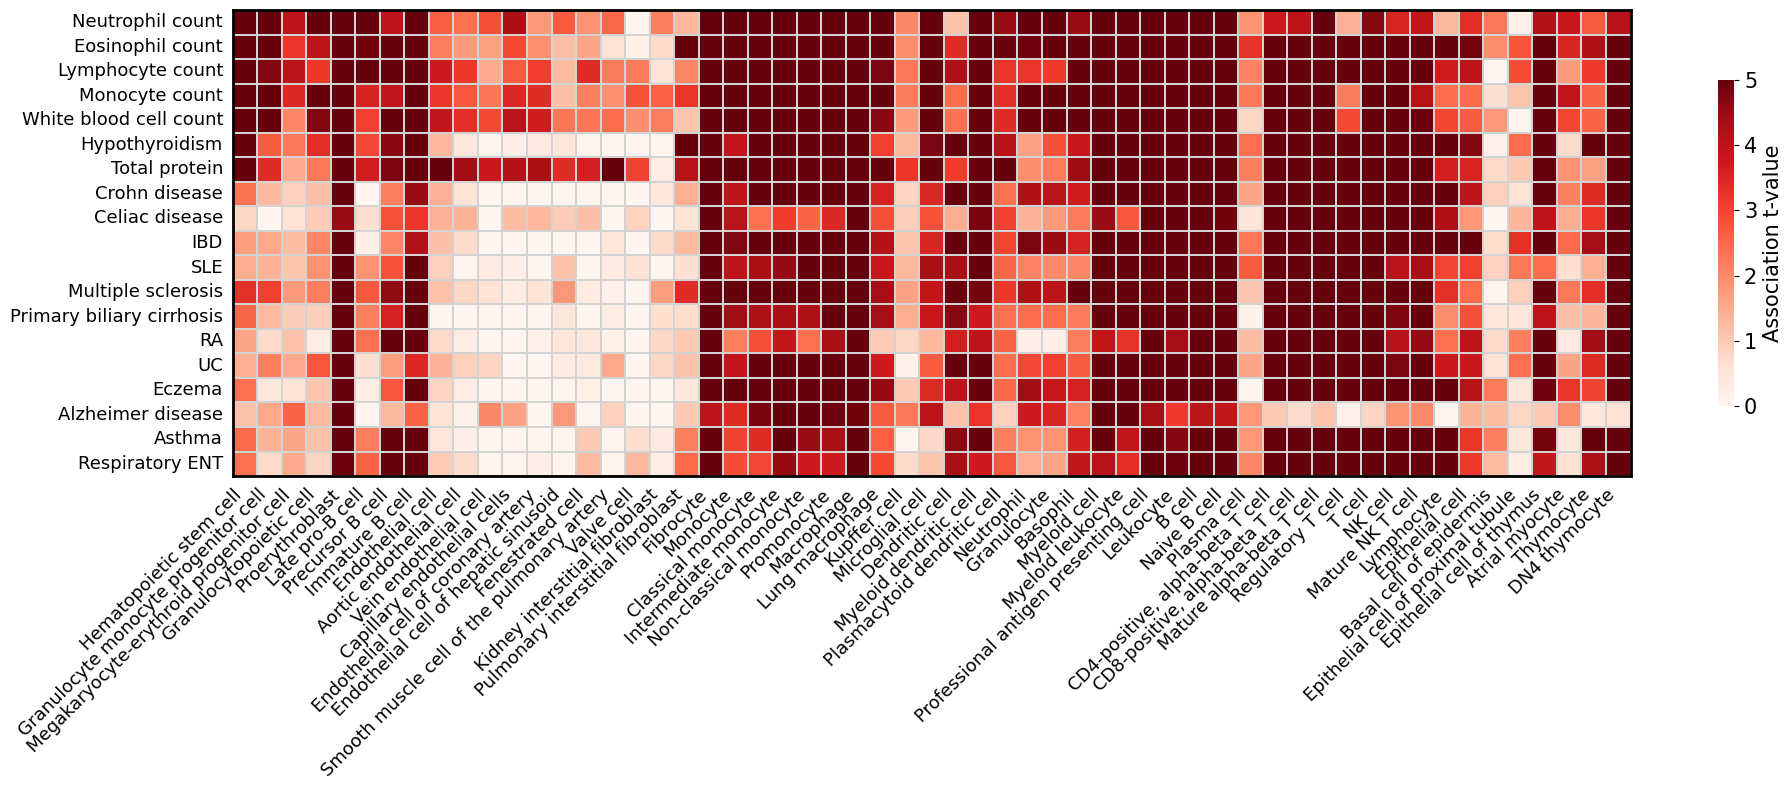

In [20]:
pivot_df = icepop_ct_df.pivot(index='trait', columns='celltype', values='z')
pivot_df = pivot_df.loc[foc_traits, :].copy()
pivot_df = pivot_df.fillna(0)
pivot_df.index = trait_name_df.loc[pivot_df.index, 'trait_short_name'].values
pivot_df.columns = ct_name_df.loc[pivot_df.columns, 'name'].values
pivot_df = pivot_df.loc[:, (pivot_df >= 2.0).sum(0) > 2]
pivot_df = pivot_df.loc[:, cell_types_ordered]

fig, ax = plt.subplots(figsize=(20, 8))
hm = sns.heatmap(
    pivot_df,
    linewidths=0.01,
    linecolor='lightgrey',
    cmap='Reds', vmin=0, vmax=5, ax=ax, cbar_kws={"shrink": 0.7},
)

ax.tick_params(left=False, bottom=False)

# make legend (colorbar) smaller
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)
cbar.set_label('Association t-value', fontsize=15)
cbar.ax.set_position([0.76, 0.4, 0.1, 0.3])

# Thicken the outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.0)   # thicker border

ax.set_xticklabels(pivot_df.columns, rotation=45, ha='right', fontsize=13)
ax.set_yticklabels(pivot_df.index, fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig("../paper/figures/graph_comp_blood_autoimmune.pdf", bbox_inches="tight")

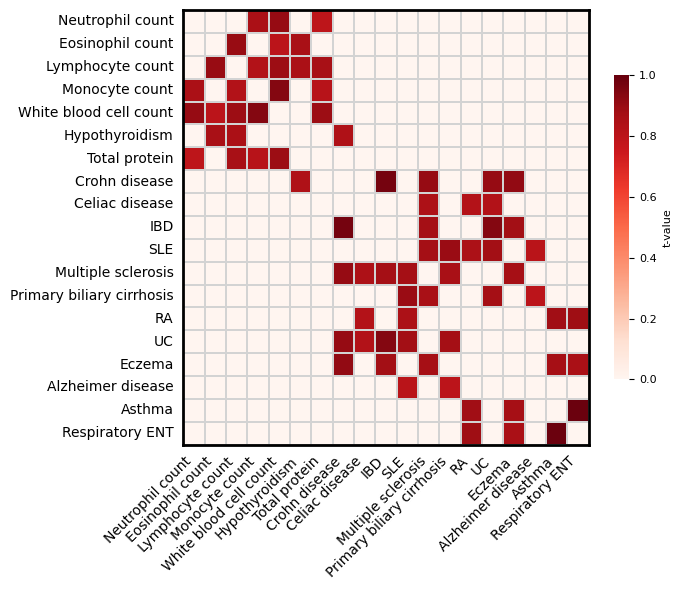

In [21]:
fig, ax = plt.subplots(figsize=(7.1, 6))
hm = sns.heatmap(
    mc_W_df.loc[pivot_df.index, pivot_df.index],
    cmap='Reds', linewidths=0.01, linecolor='lightgrey', ax=ax, cbar_kws={"shrink": 0.7},
    vmin=0.0, vmax=1.0
)

# make legend (colorbar) smaller
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label('t-value', fontsize=8)

ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')
ax.set_yticklabels(pivot_df.index)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(left=False, bottom=False)

# Thicken the outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.0)   # thicker border

plt.tight_layout()
plt.savefig("../paper/figures/graph_comp_blood_autoimmune_mcw.pdf", bbox_inches="tight")

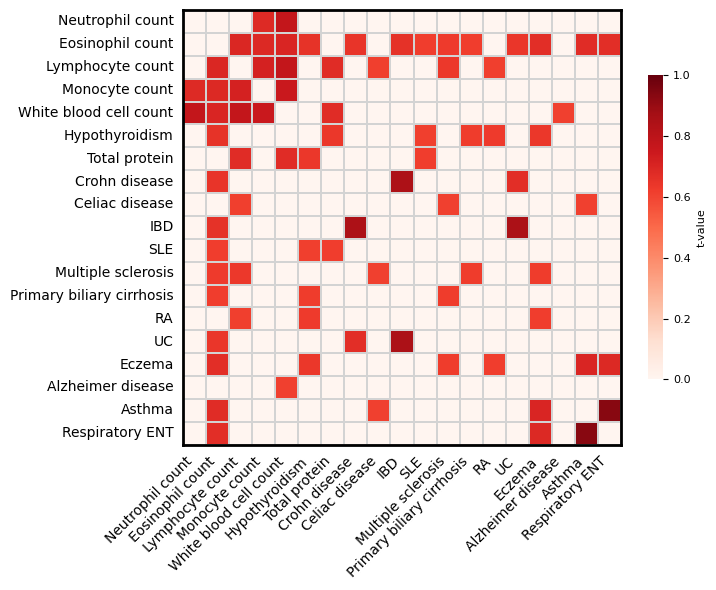

In [22]:
fig, ax = plt.subplots(figsize=(7.5, 6))
hm = sns.heatmap(
    gwasz_W_df.loc[pivot_df.index, pivot_df.index],
    cmap='Reds', linewidths=0.01, linecolor='lightgrey', ax=ax, cbar_kws={"shrink": 0.7},
    vmin=0.0, vmax=1.0
)

# make legend (colorbar) smaller
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label('t-value', fontsize=8)

ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')
ax.set_yticklabels(pivot_df.index)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(left=False, bottom=False)

# Thicken the outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.0)   # thicker border

plt.tight_layout()
plt.savefig("../paper/figures/graph_comp_blood_autoimmune_gwasw.pdf", bbox_inches="tight")

## separation of cardiovascular disease and blood pressure diease/trait

In [23]:
cv_triats = ['PASS_AtrialFibrillation_Nielsen2018', 'PASS_Coronary_Artery_Disease', 'Coronary_atherosclerosis', 'heart_failure']
bp_triats = ['UKB_460K.disease_HYPERTENSION_DIAGNOSED', 'UKB_460K.bp_DIASTOLICadjMEDz', 'UKB_460K.bp_SYSTOLICadjMEDz']
foc_traits = np.concatenate([cv_triats, bp_triats])

indir = '../results/2026-01-11__gls'

icepop_ct_df = []
for trait in foc_traits:
    df = pd.read_csv(f'{indir}/celltype__trait-{trait}.csv', header=0, index_col=None)
    df['trait'] = trait
    icepop_ct_df.append(df)
icepop_ct_df = pd.concat(icepop_ct_df, axis=0, ignore_index=True)

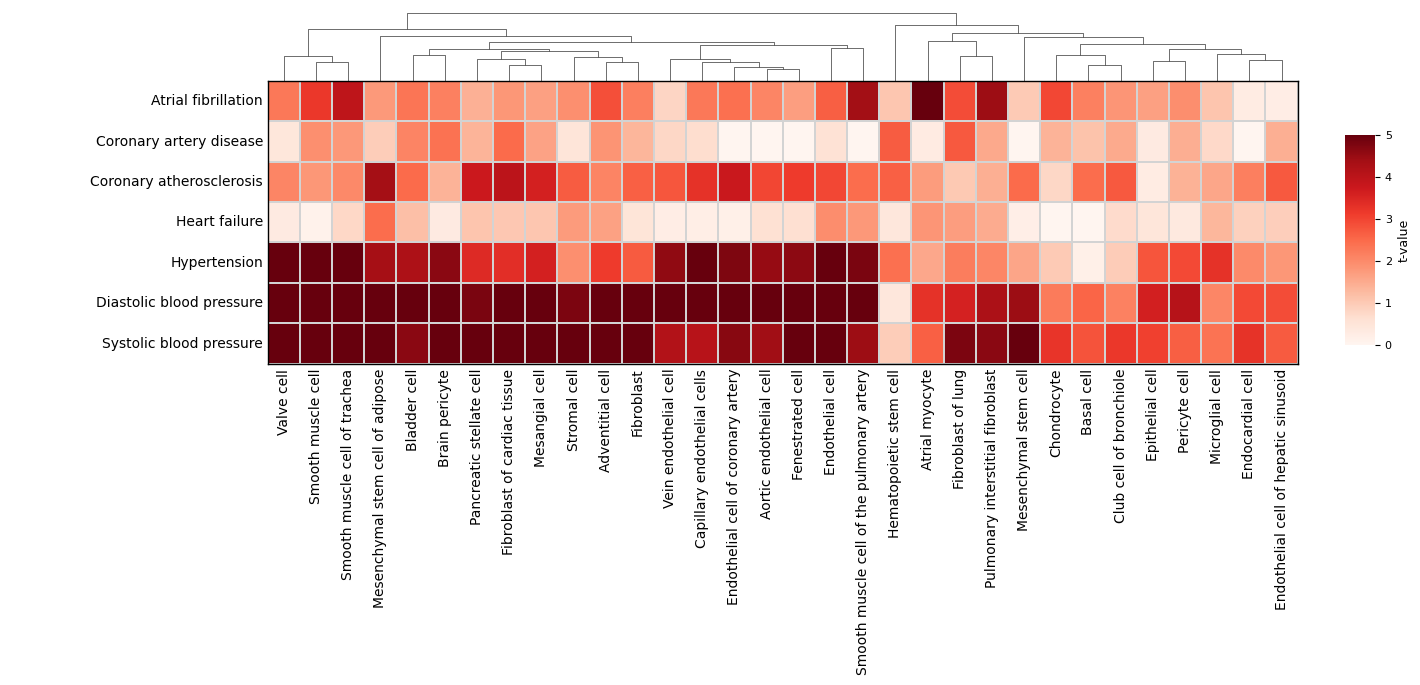

In [24]:
pivot_df = icepop_ct_df.pivot(index='trait', columns='celltype', values='z')
pivot_df = pivot_df.loc[foc_traits, :].copy()
pivot_df = pivot_df.fillna(0)
pivot_df.index = trait_name_df.loc[pivot_df.index, 'trait_short_name'].values
pivot_df.columns = ct_name_df.loc[pivot_df.columns, 'name'].values
pivot_df = pivot_df.loc[:, (pivot_df >= 2).sum(0) > 2]

g = sns.clustermap(
    pivot_df,
    row_cluster=False, col_cluster=True,
    figsize=(15, 7),
    linewidths=0.01,
    linecolor='lightgrey',
    cmap='Reds', vmin=0, vmax=5,
    cbar_pos=(0.90, 0.5, 0.02, 0.3)
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=90,
    ha="center"
)
cbar = g.ax_heatmap.collections[0].colorbar
cbar.set_label("t-value", fontsize=9)
cbar.ax.tick_params(labelsize=8)

g.ax_heatmap.yaxis.tick_left()
g.ax_heatmap.tick_params(axis="y", labelleft=True, labelright=False)

for spine in g.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)

g.ax_heatmap.tick_params(
    axis="both",
    which="both",
    length=0
)
plt.show()

## separation of hair related traits

In [25]:
hair_triats = ['UKB_460K.body_BALDING1', 'hair_color', 'UKB_460K.pigment_HAIR']
pigment_triats = ['melanoma', 'vitiligo']
foc_traits = np.concatenate([hair_triats, pigment_triats])

indir = '../results/2026-01-11__gls'

icepop_ct_df = []
for trait in foc_traits:
    df = pd.read_csv(f'{indir}/celltype__trait-{trait}.csv', header=0, index_col=None)
    df['trait'] = trait
    icepop_ct_df.append(df)
icepop_ct_df = pd.concat(icepop_ct_df, axis=0, ignore_index=True)

In [26]:
cell_types_ordered = [

    # Keratinocyte / epidermal–related
    "Bulge keratinocyte",
    "Keratinocyte",
    "Keratinocyte stem cell",
    "Basal cell",
    "Basal cell of epidermis",
    "Basal epithelial cell of tracheobronchial tree",
    "Epidermal cell",
    "Respiratory basal cell",

    # Endothelial/Epithelial cells
    "Endothelial cell",
    "Epithelial cell",
    "Epithelial cell of thymus",

    # Leukocytes
    "Immature B cell",
    "Macrophage",
    "Plasmacytoid dendritic cell",
    "T cell",
    "Mature alpha-beta T cell",
    "DN4 thymocyte",
]

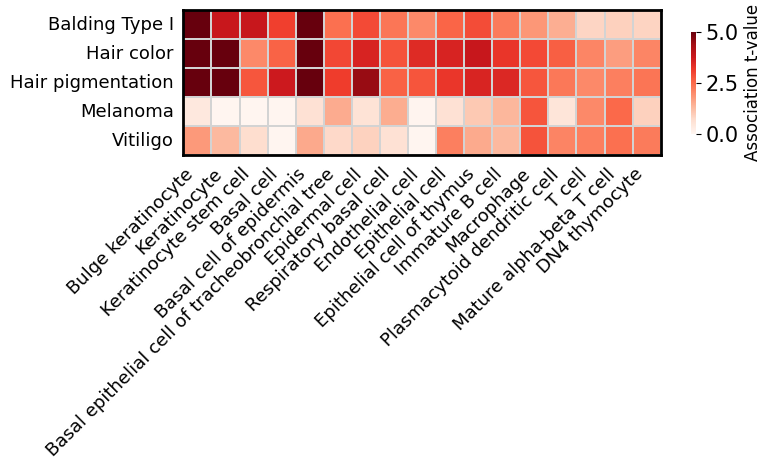

In [27]:
pivot_df = icepop_ct_df.pivot(index='trait', columns='celltype', values='z')
pivot_df = pivot_df.loc[foc_traits, :].copy()
pivot_df = pivot_df.fillna(0)
pivot_df.index = trait_name_df.loc[pivot_df.index, 'trait_short_name'].values
pivot_df.columns = ct_name_df.loc[pivot_df.columns, 'name'].values
pivot_df = pivot_df.loc[:, (pivot_df >= 2.0).sum(0) > 2]
pivot_df = pivot_df.loc[:, cell_types_ordered]

fig, ax = plt.subplots(figsize=(8, 4.8))
hm = sns.heatmap(
    pivot_df,
    linewidths=0.01,
    linecolor='lightgrey',
    cmap='Reds', vmin=0, vmax=5, ax=ax, cbar_kws={"shrink": 0.7},
)

ax.tick_params(left=False, bottom=False)

# make legend (colorbar) smaller
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)
cbar.set_label('Association t-value', fontsize=12)
cbar.ax.set_position([0.76, 0.4, 0.1, 0.3])

# Thicken the outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.0)   # thicker border

ax.set_xticklabels(pivot_df.columns, rotation=45, ha='right', fontsize=13)
ax.set_yticklabels(pivot_df.index, fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig("../paper/figures/graph_comp_hair_cell.pdf", bbox_inches="tight")

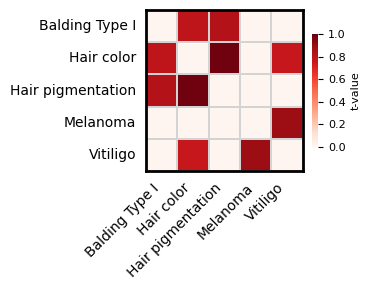

In [28]:
fig, ax = plt.subplots(figsize=(3.7, 3))
hm = sns.heatmap(
    mc_W_df.loc[pivot_df.index, pivot_df.index],
    cmap='Reds', linewidths=0.01, linecolor='lightgrey', ax=ax,
    vmin=0.0, vmax=1.0, cbar_kws={"shrink": 0.7},
)

# make legend (colorbar) smaller
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label('t-value', fontsize=8)

ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')
ax.set_yticklabels(pivot_df.index)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(left=False, bottom=False)

# Thicken the outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.0)   # thicker border

plt.tight_layout()
plt.savefig("../paper/figures/graph_comp_hair_cell_mcw.pdf", bbox_inches="tight")

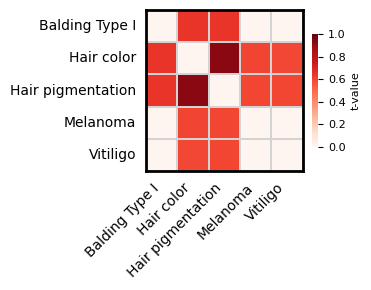

In [29]:
fig, ax = plt.subplots(figsize=(3.7, 3))
hm = sns.heatmap(
    gwasz_W_df.loc[pivot_df.index, pivot_df.index],
    cmap='Reds', linewidths=0.01, linecolor='lightgrey', ax=ax,
    vmin=0.0, vmax=1.0, cbar_kws={"shrink": 0.7},
)

# make legend (colorbar) smaller
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.set_label('t-value', fontsize=8)

ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')
ax.set_yticklabels(pivot_df.index)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(left=False, bottom=False)

# Thicken the outer border (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.0)   # thicker border

plt.tight_layout()
plt.savefig("../paper/figures/graph_comp_hair_cell_gwasw.pdf", bbox_inches="tight")

## check different resolution

In [30]:
from itertools import product
from sklearn.metrics import adjusted_rand_score

res_grid = [1.5, 2.0, 2.5, 3.0]
res_adj_df = []
for i, j in product(res_grid, res_grid):
    gwasz_labels, W, D2 = clustering_mahalanobis(
        z_mat_norm, None, distance='euclidean',
        k=3, resolution=i, random_state=42
    )

    mc_labels, W, D2 = clustering_mahalanobis(
        pc_df.to_numpy(), None, distance='euclidean',
        k=3, resolution=j, random_state=42
    )
    ARI = adjusted_rand_score(gwasz_labels, mc_labels)
    res_adj_df.append([i, j, np.unique(gwasz_labels).size, np.unique(mc_labels).size, ARI])
res_adj_df = pd.DataFrame(res_adj_df, columns=['res1', 'res2', 'gwasz_clusn', 'mc_clusn', 'ARI'])

res_adj_df.sort_values(by='ARI', ascending=False).head()

,res1,res2,gwasz_clusn,mc_clusn,ARI
9,2.5,2.0,11,11,0.404922
10,2.5,2.5,11,12,0.384751
8,2.5,1.5,11,8,0.379118
1,1.5,2.0,7,11,0.379096
2,1.5,2.5,7,12,0.370419


## compare clustering

## MC based cluster
- **Hematologic/Immune**: Neutrophil count,Eosinophil count,Lymphocyte count,Monocyte count,White blood cell count,Hypothyroidism,Total protein
- **Hematologic**: Mean corpuscular hemoglobin,Platelet count,Red blood cell distribution width,Red blood cell count
- **Autoimmune**: Crohn disease,Celiac disease,IBD,SLE,Multiple sclerosis,Primary biliary cirrhosis,RA,UC,Eczema,Alzheimer disease,Asthma,Respiratory ENT
- **?**: Vitiligo,Heart failure,IPF,Melanoma,Prostate cancer
- **Metabolic / heart / cancer**: Fasting glucose,Type 2 diabetes,Blood glucose,Testosterone male,Vitamin D,Coronary atherosclerosis,Atrial fibrillation,Coronary artery disease,Breast cancer
- **Biochem**: Alanine aminotransferase,Alkaline phosphatase,Total cholesterol,Hemoglobin A1c,HDL cholesterol,LDL cholesterol,Sex hormone binding globulin,Total bilirubin,Triglycerides,Age at menopause
- **Anthropometric / Cardiopulmonary**: WHRadjBMI,Diastolic blood pressure,Systolic blood pressure,Hypertension,FEV1 FVC ratio,Lung FVC,Heel T score,Height
- **Cognitive/Behavioral**: ASD,ADHD,General risk tolerance,Insomnia,MDD,Drinks per week,Number of children ever born
- **Psychiatric / Affective**: Basal metabolic rate,BMI,Reaction time,Schizophrenia,Subjective well being,Worry,Morning person,Smoking status
- **Psychiatric / Cognitive**: Bipolar disorder,Sleep duration,Verbal numeric reasoning,Age at menarche
- **Psychiatric / Cognitive**: Intelligence,Neuroticism,College education,Years of education
- **Pigmentation**: Hair color,Balding Type I,Hair pigmentation

## GWAS zscore based cluster
- **Hematologic/Immune**: Neutrophil count,Lymphocyte count,Monocyte count,White blood cell count,SLE,Hypothyroidism,Total protein,IPF
- **Hematologic/Immune**: Eosinophil count,Crohn disease,Celiac disease,IBD,Multiple sclerosis,Primary biliary cirrhosis,RA,UC,Eczema,Asthma,Respiratory ENT
- **Hematologic**: Mean corpuscular hemoglobin,Platelet count,Red blood cell distribution width,Red blood cell count,Total bilirubin,Age at menopause
- **Pigmentation and others**: Vitiligo,WHRadjBMI,FEV1 FVC ratio,Lung FVC,Hair color,Melanoma,Heel T score,Balding Type I,Height,Breast cancer,Hair pigmentation
- **Metabolic**: Fasting glucose,Type 2 diabetes,Blood glucose,Hemoglobin A1c
- **Biochem**: Alanine aminotransferase,Alkaline phosphatase,Total cholesterol,HDL cholesterol,LDL cholesterol,Sex hormone binding globulin,Testosterone male,Triglycerides,Vitamin D,Alzheimer disease
- **Behavioral**: Basal metabolic rate,BMI,Insomnia,Sleep duration,Age at menarche
- **Psychiatric / Cognitive**: ASD,ADHD,Intelligence,Reaction time,Verbal numeric reasoning,Morning person,Drinks per week,College education,Years of education,Smoking status,Number of children ever born
- **Psychiatric /Cognitive**: Bipolar disorder,General risk tolerance,Schizophrenia
- **Psychiatric / Affective**: MDD,Subjective well being,Worry,Neuroticism
- **Heart**: Coronary atherosclerosis,Heart failure,Atrial fibrillation,Coronary artery disease,Diastolic blood pressure,Systolic blood pressure,Hypertension,Prostate cancer

## different association
- Cancers include Breast cancer, prostate cancer and Melanoma connected differently
- Heart: Form clear cluster in GWAs Z. In mc cluster, Heart failure, Coronary atherosclerosis, Atrial fibrillation and Coronary artery disease are not clustered with other cardiovescular diseases but still connected together in the graph. in MC it separate to caridovescular and blood pressure traits
- Psychiatric traits: largely consistent
- Hematologic: largely consistent
- Biochem: largely consistent

- cancer/cardiovascular have heatmap where diease at rows and cell on columns
- also put dieasese-disease similarity based on gwas along with disease-mc association

# get metacell have differential association when cell type have similar trend

In [31]:
# load cell type res
files = Path(indir).glob('celltype__trait*.csv')
files = [str(i) for i in files]
dfs = []
for file in files:
    trait = Path(file).stem.split('__trait-')[1]
    df = pd.read_csv(file, header=0, index_col=None)
    df['trait'] = trait
    dfs.append(df)
celltype_res_df = pd.concat(dfs, axis=0, ignore_index=True)
celltype_res_df['discovery'] = celltype_res_df['q'] <= 0.1
celltypes = celltype_res_df['celltype'].unique()

# load metacell res
files = Path(indir).glob('metacell__trait*.csv')
files = [str(i) for i in files]
dfs = []
for file in files:
    trait = Path(file).stem.split('__trait-')[1]
    df = pd.read_csv(file, header=0, index_col=None)
    df['trait'] = trait
    dfs.append(df)
metacell_res_df = pd.concat(dfs, axis=0, ignore_index=True)
all_metacells = metacell_res_df['metacell'].unique()

# get cell type to metacell relationship
min_purity = 0.2
freq_df = pd.crosstab(adata.obs['cell_type'], adata.obs['SEACell'])
freq_df = freq_df.div(freq_df.sum(0))
ct2meta = {ct: np.asarray(row[row >= min_purity].index) for ct, row in freq_df.iterrows()}

# combined heatmap of metacell and cell types

In [32]:
files = Path(indir).glob('celltype__trait*.csv')
files = [str(i) for i in files]
ct_hm_df = []
for file in files:
    trait = Path(file).stem.split('__trait-')[1]
    df = pd.read_csv(file, header=0, index_col=None)
    df['discovery'] = df['q'] <= 0.1
    df = df.loc[:, ['celltype', 'discovery']].set_index('celltype')
    df = df.rename(columns={'discovery': trait})
    ct_hm_df.append(df)
ct_hm_df = pd.concat(ct_hm_df, axis=1)
ct_hm_df = ct_hm_df.T

# load metacell res
files = Path(indir).glob('metacell__trait*.csv')
files = [str(i) for i in files]
mc_zscore_df = []
for file in files:
    trait = Path(file).stem.split('__trait-')[1]
    df = pd.read_csv(file, header=0, index_col=None)
    df = df.loc[:, ['metacell', 'z']].set_index('metacell')
    df = df.rename(columns={'z': trait})
    mc_zscore_df.append(df)
mc_zscore_df = pd.concat(mc_zscore_df, axis=1)
mc_zscore_df = mc_zscore_df.T

# find case where same cell type associate differently to diseases at metacell level

In [33]:
shrink_df = []
for file in Path(indir).rglob('celltype__trait-*.csv'):
    trait = Path(file).stem.split('__trait-')[1]
    if trait not in traits:
        continue
    df = pd.read_csv(file, header=0, index_col=None)
    df['trait'] = trait
    df['discovery'] = df['q'] <= 0.1
    shrink_df.append(df)
shrink_df = pd.concat(shrink_df, ignore_index=True)
ct_df = shrink_df.pivot(index='trait', columns='celltype', values='discovery')

shrink_df = []
for file in Path(indir).rglob('metacell__trait-*.csv'):
    trait = Path(file).stem.split('__trait-')[1]
    if trait not in traits:
        continue
    df = pd.read_csv(file, header=0, index_col=None)
    df['trait'] = trait
    # df['discovery'] = df['q'] <= 0.2
    shrink_df.append(df)
shrink_df = pd.concat(shrink_df, ignore_index=True)
# mc_df = shrink_df.pivot(index='trait', columns='metacell', values='discovery')

In [34]:
def plot_umap(adata, col, cmap='Reds', palette=None, vmin=None, vmax=None, title=None, outfile=None, size=20):
    # Determine if we use custom scaling
    use_limits = isinstance(vmin, (float, int)) and isinstance(vmax, (float, int))
    
    # Generate the plot
    if palette:
        ax = sc.pl.umap(
            adata,
            color=col,
            show=False,
            size=size,
            palette=palette,
            vmin=vmin if use_limits else None,
            vmax=vmax if use_limits else None,
            alpha=0.6
        )
    else:
        ax = sc.pl.umap(
            adata,
            color=col,
            show=False,
            size=size,
            cmap=cmap,
            vmin=vmin if use_limits else None,
            vmax=vmax if use_limits else None,
            alpha=0.6
        )

    # 1. Remove the top and right "border" (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 2. Ensure bottom and left spines are visible
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

    # 3. Add ticks and labels back
    ax.set_xticks([]) # Or use ax.xaxis.set_visible(True) for default behavior
    ax.set_yticks([])
    
    # If you want numeric tick labels, use these instead:
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

    # 4. Remove title
    if not title:
        ax.set_title("")
    else:
        ax.set_title(title)

    if outfile:
        plt.tight_layout()
        plt.savefig(outfile)
    else:
        plt.show()

## CD8+ T Cells is more involved in MS
- Involvement of CD8+ T Cells in Multiple Sclerosis (https://www.frontiersin.org/journals/immunology/articles/10.3389/fimmu.2015.00604/full)
- One of the major indicators pointing toward an implication of CD8+ T cells in the pathophysiology of MS is the presence of these cells, in a greater number than CD4+ T cells, in the brain lesions of MS patients.
## CD4 T cells have major driver roles in SLE
- Normalization of CD4+ T Cell Metabolism Reverses Lupus (10.1126/scitranslmed.aaa0835)
- T Cells in Systemic Lupus Erythematosus (10.1016/j.rdc.2021.04.005)

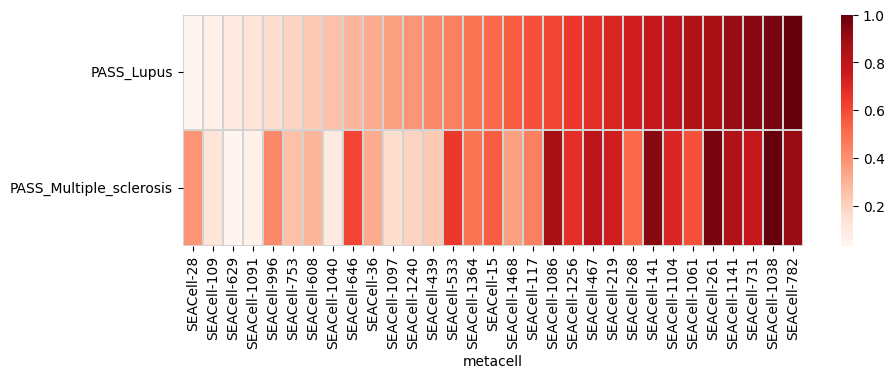

T cell


In [43]:
exp_ct = 'T cell'
dis1 = 'PASS_Lupus'
dis2 = 'PASS_Multiple_sclerosis'
mc = ct2meta[exp_ct]

score_df = mc_zscore_df.loc[[dis1, dis2], mc]
score_df = score_df.T.sort_values(by=dis1).T
mc_rank = score_df.loc[dis1, :].rank() / mc.size - score_df.loc[dis2, :].rank() / mc.size

rank_df = score_df.rank(1) / mc.size

plt.figure(figsize=(10, 3))
g = sns.heatmap(
    rank_df,
    linewidths=0.01,
    linecolor='#d3d3d3',
    cmap='Reds'
)
plt.show()
print(exp_ct)

In [44]:
def umap_filter(adata, pct=99.9):
    X = adata.obsm["X_umap"]
    x, y = X[:, 0], X[:, 1]
    
    mask = (
        (x > np.percentile(x, 100 - pct)) &
        (x < np.percentile(x, pct)) &
        (y > np.percentile(y, 100 - pct)) &
        (y < np.percentile(y, pct))
    )
    n_remove = adata.shape[0] - mask.sum()
    print(f'{n_remove} cell removed')
    return adata[mask, :].copy()

155 cell removed


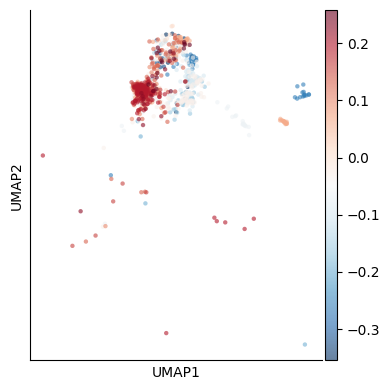

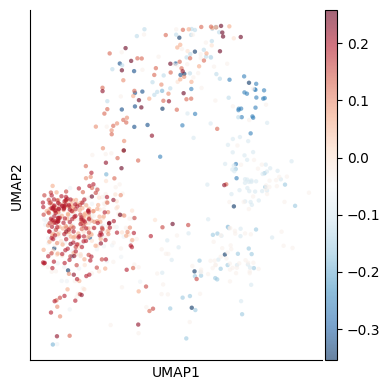

In [52]:
sub_adata = adata[
    (adata.obs['cell_type'] == exp_ct) &
    (adata.obs['SEACell'].isin(mc))
].copy()

dis1_df = shrink_df[shrink_df['trait'] == dis1].copy()
dis1_df = dis1_df.set_index('metacell')
dis1_df = dis1_df.loc[mc, :].copy()
dis2_df = shrink_df[shrink_df['trait'] == dis2].copy()
dis2_df = dis2_df.set_index('metacell')
dis2_df = dis2_df.loc[mc, :].copy()

rank_diff = dis1_df['z'].rank() / mc.size - dis2_df['z'].rank() / mc.size
tit_name = '%s vs. %s' % (trait_df.loc[dis1, 'trait_short_name'], trait_df.loc[dis2, 'trait_short_name'])
sub_adata.obs[tit_name] = list(rank_diff.loc[(sub_adata.obs['SEACell'])])
# sc.pl.umap(sub_adata, color=[tit_name], cmap='RdBu_r')
plot_umap(sub_adata, tit_name, cmap='RdBu_r', outfile='../paper/figures/SLE_MS_full.pdf', size=40)

sub_adata = umap_filter(sub_adata, 95)
plot_umap(sub_adata, tit_name, cmap='RdBu_r', outfile='../paper/figures/SLE_MS.pdf', size=40)

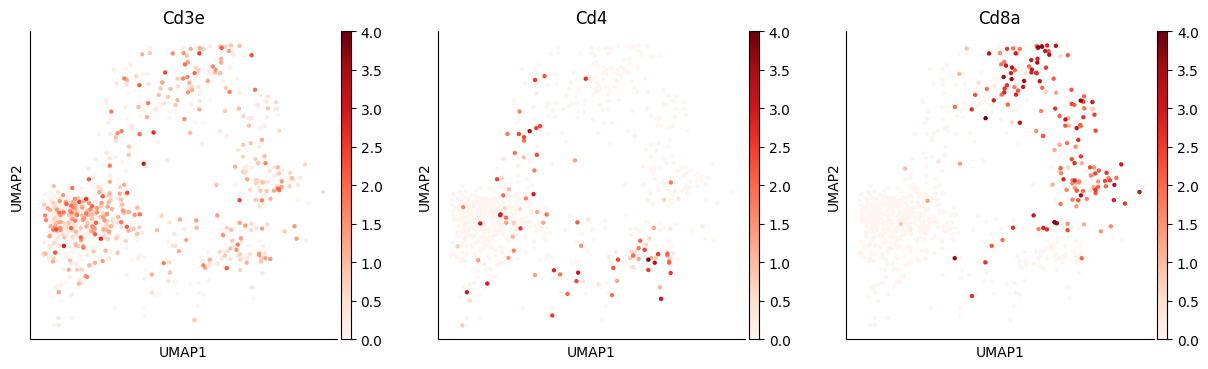

In [38]:
sc.pl.umap(sub_adata, color=['Cd3e', 'Cd4', 'Cd8a'], cmap='Reds', vmax=4, size=40, show=False)
plt.savefig('../paper/figures/SLE_MS_gene_sig.pdf')

## Surface GC is more related to UC
### Differences in goblet cell differentiation between Crohn's disease and ulcerative colitis (10.1016/j.diff.2008.09.008)
- The proportion of goblet cells was lowered in both IBDs, but specifically diminished in the upper third of the crypt in UC.
### An intercrypt subpopulation of goblet cells is essential for colonic mucus barrier function (10.1126/science.abb1590)
- In the colon, the most differentiated GCs are the high–mucus turnover cells localized to the surface epithelium between crypts, which were designated as intercrypt GCs (icGCs). These cells had expression profiles that were distinct from those of crypt-resident.
- The icGCs possess a specific role in mucus organization, where their malfunction is associated with colitis in both mice and humans.
- The two colonic clusters of fully differentiated GCs (clusters 7 and 8, Mxd1+) expressed many genes in common, but they differed because cluster 8 expressed several genes shared with non-GC epithelial cells (Fig. 2, A and B). Markers for these GCs were only detected at the surface epithelium in the intercrypt area (Fig. 3C). 

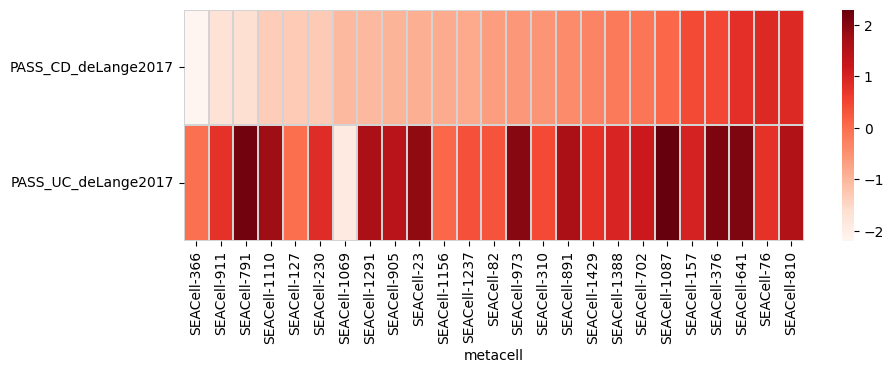

large intestine goblet cell


In [39]:
exp_ct = 'large intestine goblet cell'
dis1 = 'PASS_CD_deLange2017'
dis2 = 'PASS_UC_deLange2017'
mc = ct2meta[exp_ct]

score_df = mc_zscore_df.loc[[dis1, dis2], mc]
score_df = score_df.T.sort_values(by=dis1).T
mc_rank = score_df.loc[dis1, :].rank() / mc.size - score_df.loc[dis2, :].rank() / mc.size

plt.figure(figsize=(10, 3))
g = sns.heatmap(
    score_df,
    linewidths=0.01,
    linecolor='#d3d3d3',
    cmap='Reds'
)
plt.show()
print(exp_ct)

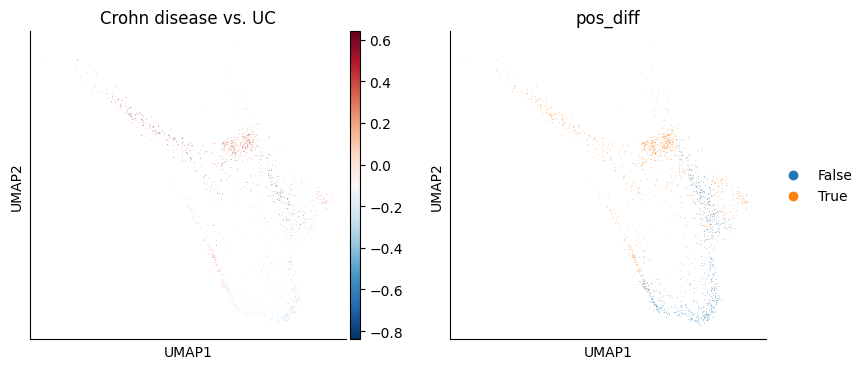

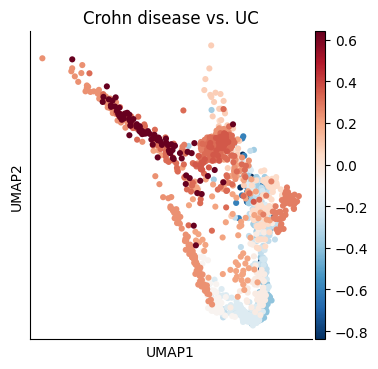

In [40]:
sub_adata = adata[
    (adata.obs['cell_type'] == exp_ct) &
    (adata.obs['SEACell'].isin(mc))
].copy()

dis1_df = shrink_df[shrink_df['trait'] == dis1].copy()
dis1_df = dis1_df.set_index('metacell')
dis1_df = dis1_df.loc[mc, :].copy()
dis2_df = shrink_df[shrink_df['trait'] == dis2].copy()
dis2_df = dis2_df.set_index('metacell')
dis2_df = dis2_df.loc[mc, :].copy()

rank_diff = dis1_df['z'].rank() / mc.size - dis2_df['z'].rank() / mc.size
tit_name = '%s vs. %s' % (trait_df.loc[dis1, 'trait_short_name'], trait_df.loc[dis2, 'trait_short_name'])
sub_adata.obs[tit_name] = list(rank_diff.loc[(sub_adata.obs['SEACell'])])
sub_adata.obs['pos_diff'] = list((rank_diff.loc[sub_adata.obs['SEACell']] > 0).astype(str))
sc.pl.umap(sub_adata, color=[tit_name, 'pos_diff'], cmap='RdBu_r', s=1)
sc.pl.umap(sub_adata, color=[tit_name], cmap='RdBu_r')

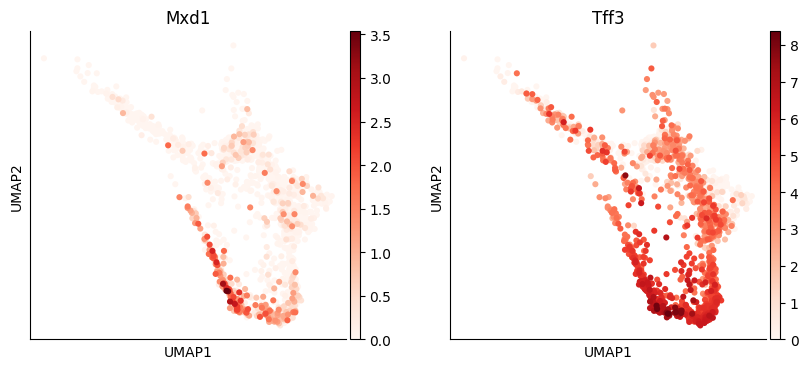

In [41]:
sc.pl.umap(sub_adata, color=['Mxd1', 'Tff3'], cmap='Reds')